# 02. Transaction-Level Behavior

## Goal

The goal of this notebook is to compare known business and consumer transactions at the transaction level

## Why this matters

The final goal is to identify consumer cards with business-like behavior. Before building card-level features and ML models, we need to understand which transaction-level patterns distinguish known business cards from consumer cards.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from mdq.data import load_data

sns.set_theme(style="whitegrid", palette="muted")


In [2]:
business, consumer, merchant, mcc = load_data()

In [3]:
merchants_no_mcc = merchant.drop(columns=["mcc"])

mcc_ref = mcc[["mcc", "mcc_name"]].copy()
mcc_ref["mcc"] = mcc_ref["mcc"].astype(str).str.zfill(4)

business_txn = business.copy()
consumer_txn = consumer.copy()

business_txn["segment"] = "business"
consumer_txn["segment"] = "consumer"

for df in [business_txn, consumer_txn]:
    df["mcc"] = df["mcc"].astype(str).str.zfill(4)

business_txn = business_txn.merge(
    merchants_no_mcc,
    on="merchant_id",
    how="left",
    validate="many_to_one"
).merge(
    mcc_ref,
    on="mcc",
    how="left",
    validate="many_to_one"
)

consumer_txn = consumer_txn.merge(
    merchants_no_mcc,
    on="merchant_id",
    how="left",
    validate="many_to_one"
).merge(
    mcc_ref,
    on="mcc",
    how="left",
    validate="many_to_one"
)

txns = pd.concat([business_txn, consumer_txn], ignore_index=True)

In [4]:
pd.options.display.float_format = "{:,.2f}".format

amount_summary = pd.DataFrame({
    "business": business_txn["transaction_amount_kzt"].describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.999]
    ),
    "consumer": consumer_txn["transaction_amount_kzt"].describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.999]
    ),
})

amount_summary

,business,consumer
count,"2,997,593.00","9,832,487.00"
mean,"156,535.27","54,045.42"
std,"252,868.24","169,654.63"
min,67.00,15.00
50%,"77,224.00","11,892.00"
75%,"196,081.00","39,665.00"
90%,"381,918.60","117,999.00"
95%,"566,273.00","222,106.00"
99%,"1,090,844.96","699,869.00"
99.9%,"2,546,924.98","2,151,534.90"


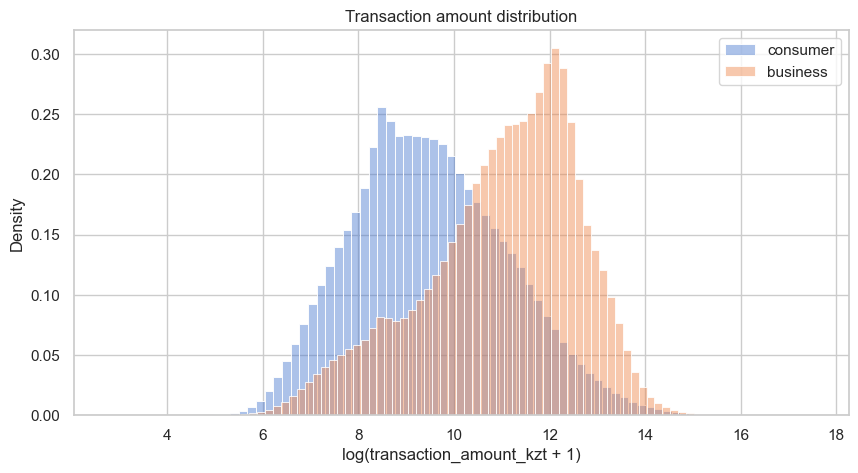

In [5]:
plt.figure(figsize=(10, 5))

sns.histplot(
    np.log1p(consumer_txn["transaction_amount_kzt"]),
    bins=80,
    stat="density",
    label="consumer",
    alpha=0.45
)

sns.histplot(
    np.log1p(business_txn["transaction_amount_kzt"]),
    bins=80,
    stat="density",
    label="business",
    alpha=0.45
)

plt.title("Transaction amount distribution")
plt.xlabel("log(transaction_amount_kzt + 1)")
plt.ylabel("Density")
plt.legend()
plt.show()

Finding

Business transactions tend to be much larger than consumer transactions. The median business transaction is 77,224 KZT, compared to 11,892 KZT for consumers. On a log scale, business transactions are also shifted to the right, showing that high-value payments happen more often in the business segment.

Card-level feature implication

Because the final model will use card-level data, we should turn this finding into amount-based features for each card:

* avg_amount
* median_amount
* max_amount
* total_spend

These features describe whether a card usually makes larger payments, not just whether one transaction was large.

In [6]:
thresholds = [10_000, 50_000, 100_000, 500_000]

large_txn_compare = pd.DataFrame([
    {
        "threshold": f">= {t:,.0f}",
        "business": (business_txn["transaction_amount_kzt"] >= t).mean(),
        "consumer": (consumer_txn["transaction_amount_kzt"] >= t).mean(),
    }
    for t in thresholds
])

large_txn_compare

,threshold,business,consumer
0,">= 10,000",0.85,0.54
1,">= 50,000",0.60,0.21
2,">= 100,000",0.44,0.12
3,">= 500,000",0.06,0.02


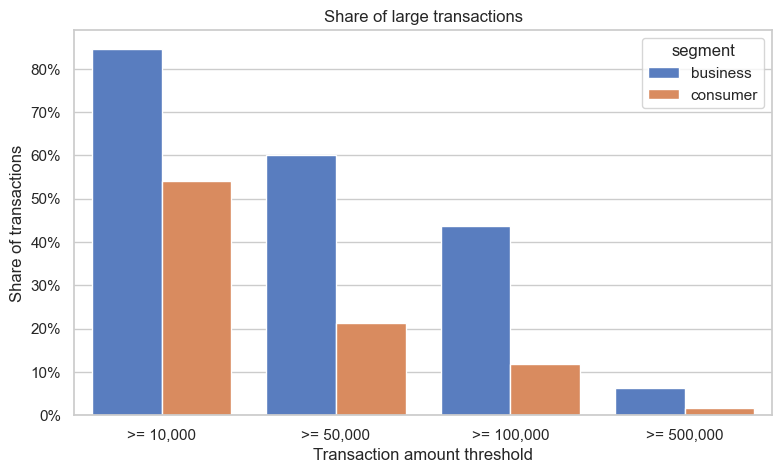

In [7]:
plot_df = large_txn_compare.melt(
    id_vars="threshold",
    var_name="segment",
    value_name="share"
)

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="threshold", y="share", hue="segment")
plt.title("Share of large transactions")
plt.xlabel("Transaction amount threshold")
plt.ylabel("Share of transactions")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.show()

### Finding

Business cards have much more large transactions than consumer cards.

For example, 60.2% of business transactions are higher than 50,000 KZT, but for consumer it is only 21.2%. For 100,000 KZT threshold, business has 43.7%, while consumer has only 11.8%.

So this confirms that business cards usually do not just spend more in total, they also make large payments more often.

### Card-level feature idea

Later our model will work on card level, not transaction level. So we should turn this pattern into card-level features.

For each card we can calculate:

- `share_txn_ge_10k`
- `share_txn_ge_50k`
- `share_txn_ge_100k`
- `share_txn_ge_500k`

These features show how often a card makes large payments.

This is useful because one big transaction can happen for a normal consumer too. But if a card often has payments above 50k or 100k, then it starts to look more business-like.

In [8]:
channel_compare = pd.concat([
    business_txn["channel"].value_counts(normalize=True).rename("business"),
    consumer_txn["channel"].value_counts(normalize=True).rename("consumer"),
], axis=1).fillna(0)

channel_compare

,business,consumer
channel,,
online,0.85,0.47
POS,0.15,0.53


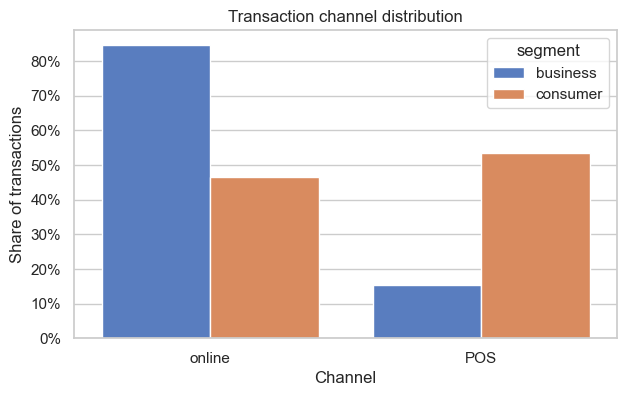

In [9]:
plot_df = channel_compare.reset_index().melt(
    id_vars="channel",
    var_name="segment",
    value_name="share"
)

plt.figure(figsize=(7, 4))
sns.barplot(data=plot_df, x="channel", y="share", hue="segment")
plt.title("Transaction channel distribution")
plt.xlabel("Channel")
plt.ylabel("Share of transactions")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.show()

### Finding

Business transactions are much more online-heavy than consumer transactions.

Around 84.7% of business transactions are online, while for consumer it is only 46.5%. On the other side, POS transactions are more common for consumer cards: 53.5% compared to only 15.3% for business.

So business cards are used more through online channel, while consumer cards are more mixed and slightly more POS-heavy.

### Card-level feature idea

Later the model will work on card level, so we should convert this transaction-level pattern into card-level features.

For each card we can calculate:

- `online_ratio`
- `pos_ratio`

For ml we should use one of them cause online_ratio + pos_ratio = 1.
These features show how much a card is used online or offline.

This can be useful because business-like cards may have a high online share, especially if they are used for ads, software, subscriptions, platforms or other digital services.

In [10]:
payment_compare = pd.DataFrame({
    "business": [
        business_txn["is_recurring"].mean(),
        business_txn["tokenized"].mean(),
        business_txn["recurring_capable"].mean(),
    ],
    "consumer": [
        consumer_txn["is_recurring"].mean(),
        consumer_txn["tokenized"].mean(),
        consumer_txn["recurring_capable"].mean(),
    ],
}, index=[
    "is_recurring",
    "tokenized",
    "recurring_capable_merchant",
])

payment_compare

,business,consumer
is_recurring,0.13,0.03
tokenized,0.60,0.39
recurring_capable_merchant,0.32,0.07


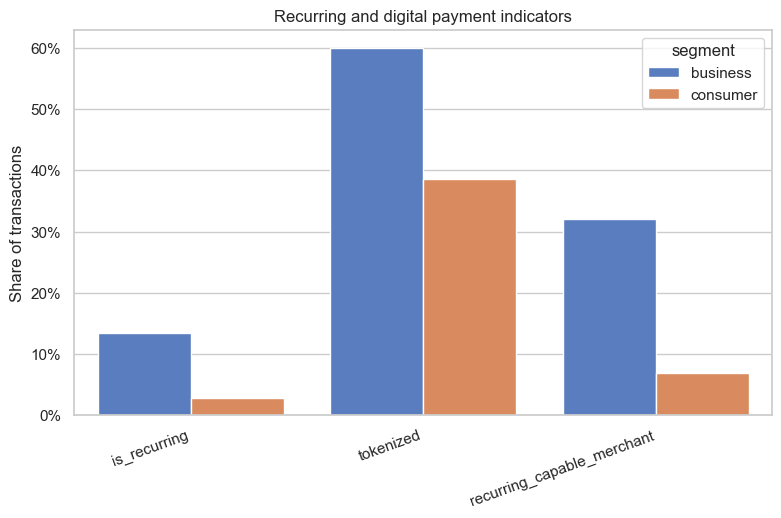

In [11]:
plot_df = payment_compare.reset_index(names="metric").melt(
    id_vars="metric",
    var_name="segment",
    value_name="share"
)

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="metric", y="share", hue="segment")
plt.title("Recurring and digital payment indicators")
plt.xlabel("")
plt.ylabel("Share of transactions")
plt.xticks(rotation=20, ha="right")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.show()

### Finding

Business transactions are more connected with recurring and digital payments.

Recurring transactions are 13.3% for business and only 2.7% for consumer. Also 32.1% of business transactions are at recurring-capable merchants, while consumer has only 6.9%.

Business transactions are also more often tokenized. Business has 60.0%, consumer has 38.6%. So business cards look more connected with saved-card payments, subscriptions, ads, software, platforms and online services.

### Card-level feature idea

Later we will move this to card level.

For each card we can calculate:

- `is_recurring_ratio`
- `recurring_capable_ratio`
- `tokenized_ratio`

These features show how often the card is used in recurring or digital payment patterns.

It can help us find hidden entrepreneurs because they may use consumer cards for work payments like ads, software, subscriptions and platforms.

In [12]:
for df in [business_txn, consumer_txn]:
    df["ts"] = pd.to_datetime(df["transaction_timestamp"])
    df["hour"] = df["ts"].dt.hour
    df["dow"] = df["ts"].dt.dayofweek
    df["month"] = df["ts"].dt.to_period("M").astype(str)
    df["is_weekend"] = df["dow"] >= 5
    df["weekday_business_hours"] = (df["dow"] < 5) & df["hour"].between(9, 18)
    df["weekday_non_business_hours"] = (df["dow"] < 5) & ~df["hour"].between(9, 18)

In [13]:
time_cols = ["weekday_business_hours", "weekday_non_business_hours", "is_weekend"]

time_compare = pd.DataFrame({
    "business": business_txn[time_cols].mean(),
    "consumer": consumer_txn[time_cols].mean(),
})

time_compare

,business,consumer
weekday_business_hours,0.65,0.40
weekday_non_business_hours,0.23,0.25
is_weekend,0.12,0.35


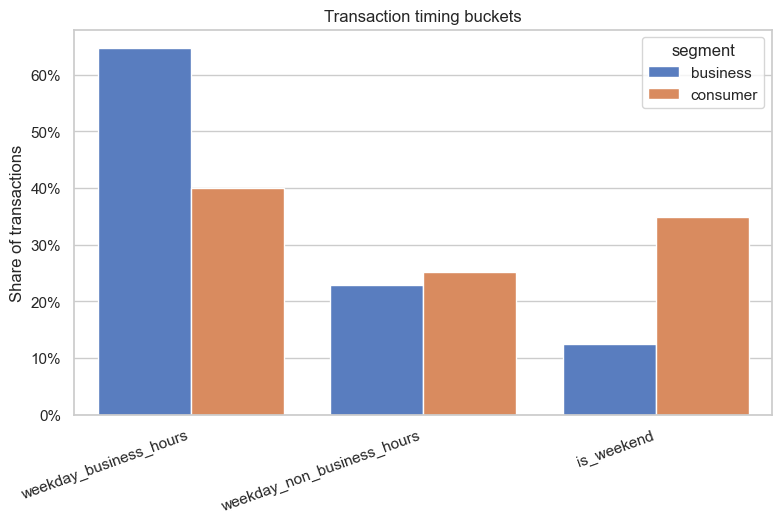

In [14]:
plot_df = time_compare.reset_index(names="time_bucket").melt(
    id_vars="time_bucket",
    var_name="segment",
    value_name="share"
)

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="time_bucket", y="share", hue="segment")
plt.title("Transaction timing buckets")
plt.xlabel("")
plt.ylabel("Share of transactions")
plt.xticks(rotation=20, ha="right")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.show()

### Finding

Business and consumer transactions happen at different times.

Most business transactions happen during weekday business hours. For business it is 64.7%, while for consumer it is 40.0%.

Consumer transactions are much more active on weekends. Weekend share is 34.8% for consumer and only 12.5% for business.

Weekday non-business hours are quite close for both segments. Business has 22.8%, consumer has 25.2%. So the main difference is not evening weekdays, but business hours vs weekends.

### Card-level feature idea

Later we will move this to card level.

For each card we can calculate:

- `weekday_business_hours_ratio`
- `weekday_non_business_hours_ratio`
- `weekend_ratio`

These features show when the card is usually used.

This can help us find hidden entrepreneurs because business-like cards may be used more during working days and less on weekends.

In [15]:
hourly = pd.DataFrame({
    "business": business_txn["hour"].value_counts(normalize=True).sort_index(),
    "consumer": consumer_txn["hour"].value_counts(normalize=True).sort_index(),
})

hourly

,business,consumer
hour,,
0,0.02,0.01
1,0.02,0.01
2,0.02,0.01
3,0.02,0.01
4,0.02,0.01
5,0.02,0.01
6,0.01,0.01
7,0.02,0.02
8,0.04,0.04


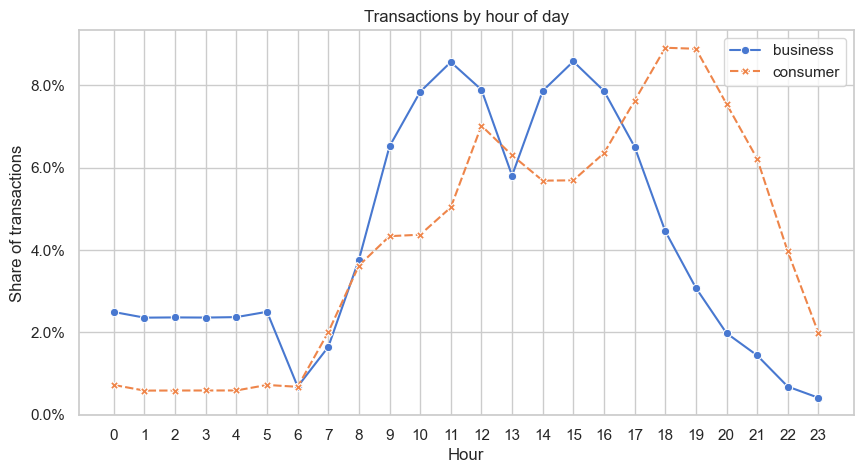

In [16]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly, markers=True)
plt.title("Transactions by hour of day")
plt.xlabel("Hour")
plt.ylabel("Share of transactions")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
plt.xticks(range(0, 24))
plt.show()

### Finding

Hourly transaction patterns show some difference, but it is not as clean as the previous time-bucket analysis.

Business transactions are more active during daytime working hours, especially around 10–12 and 14–16. Consumer transactions are more active in the evening, especially around 18–20.

However, the hourly pattern is more detailed and noisier than the simple time buckets. The previous three-bucket split gives a cleaner and more stable signal:

- weekday business hours
- weekday non-business hours
- weekend

### Feature engineering decision
Hourly features may be tested later only if the baseline model needs more time-based detail.

In [17]:
monthly = pd.DataFrame({
    "business": business_txn["month"].value_counts(normalize=True).sort_index(),
    "consumer": consumer_txn["month"].value_counts(normalize=True).sort_index(),
})

monthly

,business,consumer
month,,
2025-10,0.17,0.16
2025-11,0.17,0.16
2025-12,0.16,0.20
2026-01,0.17,0.16
2026-02,0.17,0.16
2026-03,0.17,0.16


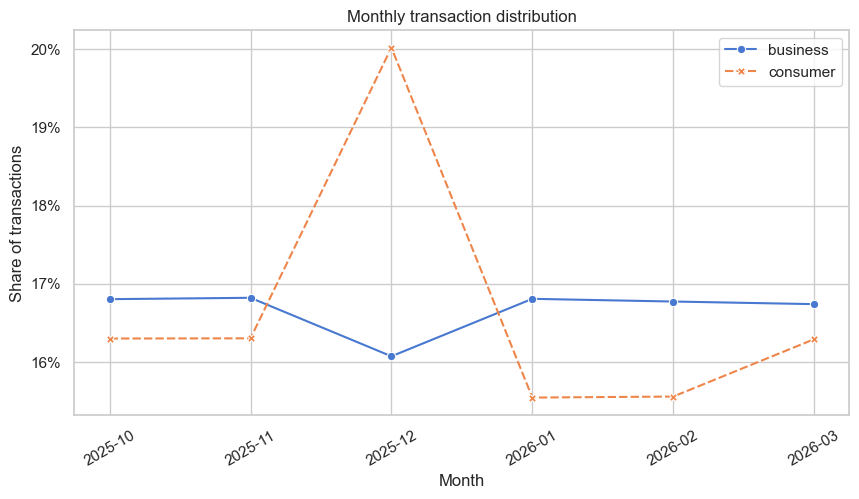

In [18]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly, markers=True)
plt.title("Monthly transaction distribution")
plt.xlabel("Month")
plt.ylabel("Share of transactions")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.xticks(rotation=30)
plt.show()

### Finding

Monthly distribution does not show a strong and stable difference between business and consumer.

Business transactions are almost evenly distributed across months, around 16–17% each month. Consumer transactions have a visible spike in December, around 20%, and lower shares in January and February.

This may be related to seasonal consumer spending, for example holidays or year-end shopping. But this pattern is not enough to say that month strongly separates business and consumer behavior.

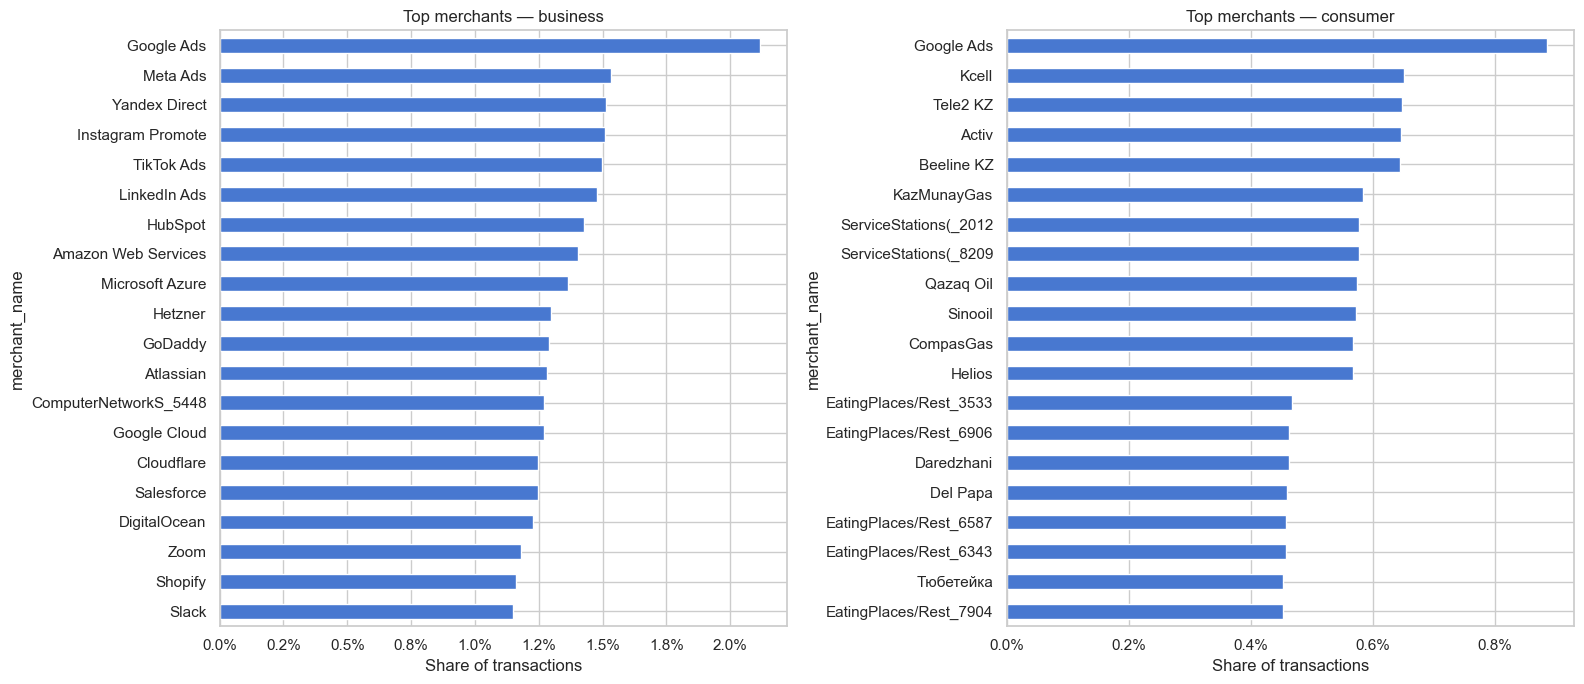

In [19]:
top_n = 20

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

business_txn["merchant_name"].value_counts(normalize=True).head(top_n).sort_values().plot(
    kind="barh",
    ax=axes[0],
    title="Top merchants — business"
)

consumer_txn["merchant_name"].value_counts(normalize=True).head(top_n).sort_values().plot(
    kind="barh",
    ax=axes[1],
    title="Top merchants — consumer"
)

for ax in axes:
    ax.set_xlabel("Share of transactions")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))

plt.tight_layout()
plt.show()

In [20]:
for name, df in [("business", business_txn), ("consumer", consumer_txn)]:
    print(name)
    display(
        df[df["merchant_id"] == "MER_000000"]
        .groupby(["merchant_id", "merchant_name", "mcc", "mcc_name"])
        .size()
        .sort_values(ascending=False)
        .reset_index(name="rows")
    )

business


,merchant_id,merchant_name,mcc,mcc_name,rows
0,MER_000000,Google Ads,7311,Advertising Services,45749
1,MER_000000,Google Ads,7012,Timeshares,17701


consumer


,merchant_id,merchant_name,mcc,mcc_name,rows
0,MER_000000,Google Ads,7311,Advertising Services,43869
1,MER_000000,Google Ads,7012,Timeshares,43150


In [21]:
for df in [business_txn, consumer_txn]:
    df["merchant_name_clean"] = df["merchant_name"]

    mask = (df["merchant_id"] == "MER_000000") & (df["mcc"] == "7012")

    df.loc[mask, "merchant_name_clean"] = "Timeshare / Lodging placeholder"

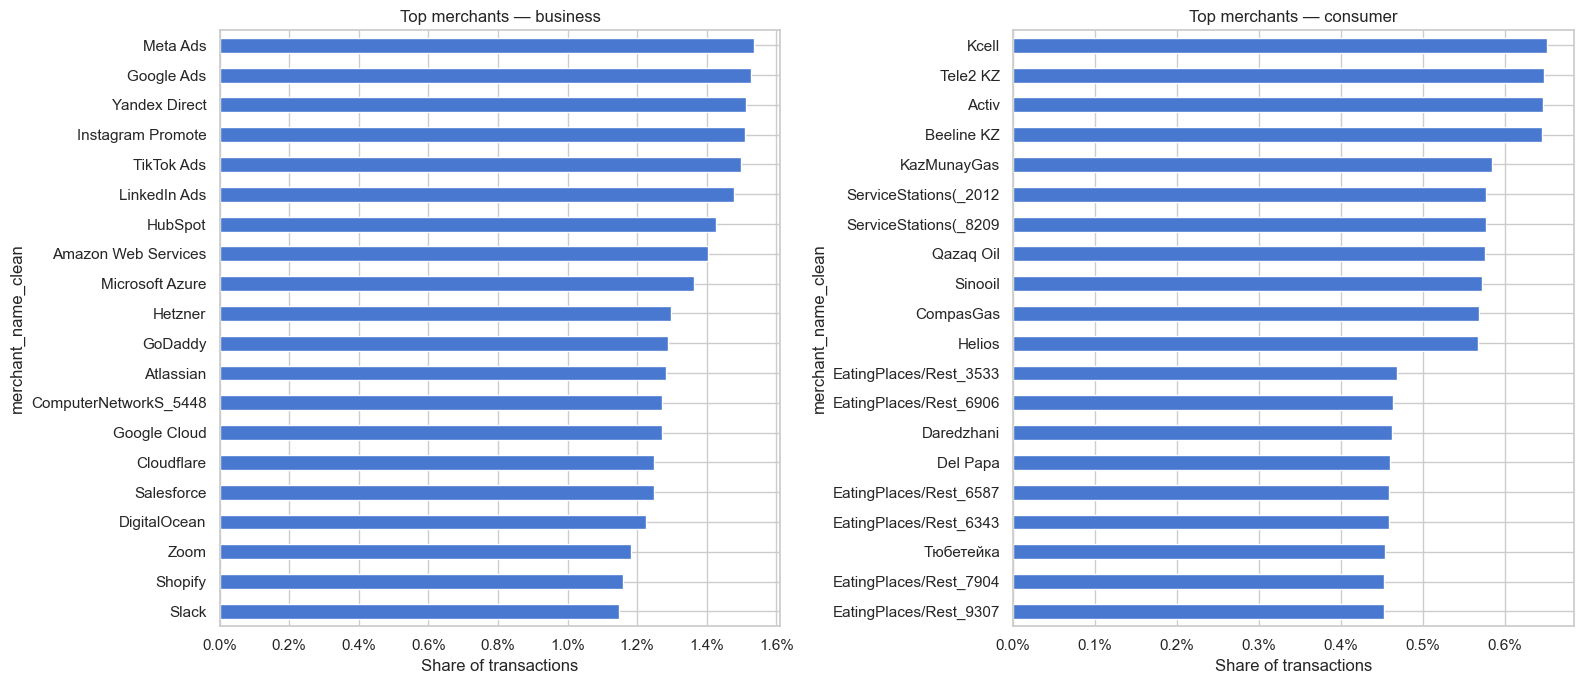

In [22]:
top_n = 20

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

business_txn["merchant_name_clean"].value_counts(normalize=True).head(top_n).sort_values().plot(
    kind="barh",
    ax=axes[0],
    title="Top merchants — business"
)

consumer_txn["merchant_name_clean"].value_counts(normalize=True).head(top_n).sort_values().plot(
    kind="barh",
    ax=axes[1],
    title="Top merchants — consumer"
)

for ax in axes:
    ax.set_xlabel("Share of transactions")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))

plt.tight_layout()
plt.show()

### Finding

After separating the suspicious `MER_000000 + MCC 7012` rows, the top merchant pattern is clearer.

Business top merchants are mostly digital and work-related services such as ads platforms, cloud providers, hosting, CRM, software tools and collaboration platforms.

Consumer top merchants look more like everyday spending. The top list includes mobile operators, gas stations, restaurants and food places.

This supports the previous findings. Business transactions are more connected with digital and operational expenses, while consumer transactions are more connected with daily personal spending.

### Feature engineering decision

We will not use raw merchant names as main model features.

Raw merchant names can overfit to this dataset. For example, Google Ads or Meta Ads may be very strong here, but a more stable feature is the category of spending.

So this analysis mainly supports creating card-level category ratios such as:

- `advertising_ratio`
- `software_cloud_ratio`
- `business_services_ratio`
- `logistics_ratio`
- `restaurant_ratio`
- `fuel_ratio`

These features are easier to explain and more general than individual merchant names.

In [23]:
merchant_compare = pd.concat([
    business_txn["merchant_name"].value_counts(normalize=True).rename("business_share"),
    consumer_txn["merchant_name"].value_counts(normalize=True).rename("consumer_share"),
], axis=1).fillna(0)

merchant_compare["diff_pp"] = (
    merchant_compare["business_share"] - merchant_compare["consumer_share"]
) * 100

merchant_compare["ratio_biz_to_consumer"] = (
    merchant_compare["business_share"] /
    merchant_compare["consumer_share"].replace(0, np.nan)
)

merchant_over = merchant_compare.sort_values("diff_pp", ascending=False).head(20)
merchant_over

,business_share,consumer_share,diff_pp,ratio_biz_to_consumer
merchant_name,,,,
HubSpot,0.01,0.00,1.35,18.66
Amazon Web Services,0.01,0.00,1.33,17.91
Microsoft Azure,0.01,0.00,1.29,17.67
Hetzner,0.01,0.00,1.24,21.89
GoDaddy,0.01,0.00,1.23,22.96
Google Ads,0.02,0.01,1.23,2.39
ComputerNetworkS_5448,0.01,0.00,1.22,24.09
Atlassian,0.01,0.00,1.20,16.05
Google Cloud,0.01,0.00,1.19,15.97


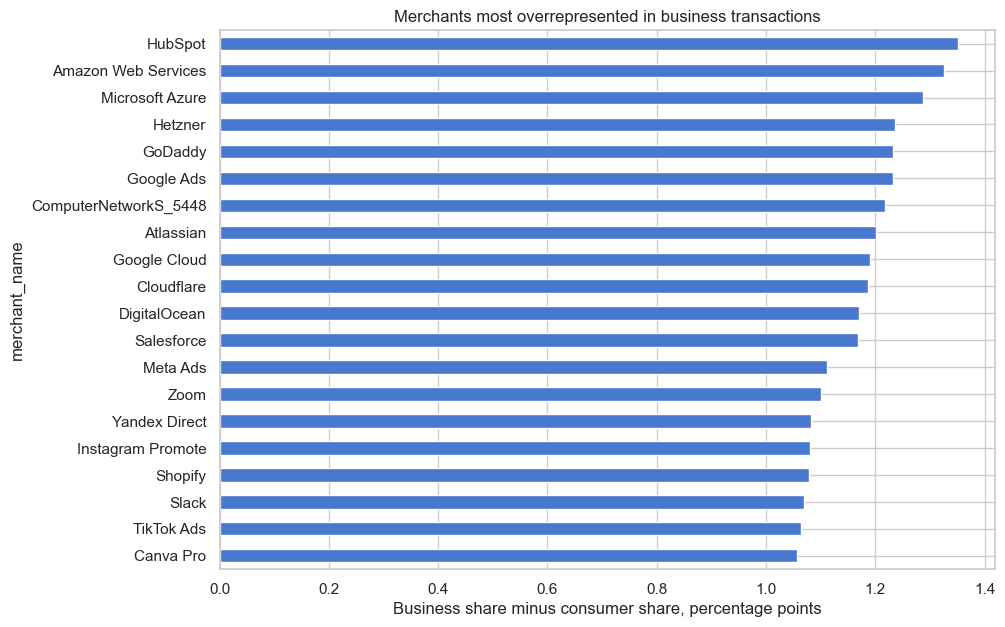

In [24]:
plt.figure(figsize=(10, 7))
merchant_over["diff_pp"].sort_values().plot(kind="barh")
plt.title("Merchants most overrepresented in business transactions")
plt.xlabel("Business share minus consumer share, percentage points")
plt.show()

In [25]:
mcc_compare = pd.concat([
    business_txn["mcc_name"].value_counts(normalize=True).rename("business_share"),
    consumer_txn["mcc_name"].value_counts(normalize=True).rename("consumer_share"),
], axis=1).fillna(0)

mcc_compare["diff_pp"] = (
    mcc_compare["business_share"] - mcc_compare["consumer_share"]
) * 100

mcc_compare["ratio_biz_to_consumer"] = (
    mcc_compare["business_share"] /
    mcc_compare["consumer_share"].replace(0, np.nan)
)

mcc_business_over = mcc_compare.sort_values("diff_pp", ascending=False).head(20)
mcc_consumer_over = mcc_compare.sort_values("diff_pp", ascending=True).head(20)

mcc_business_over

,business_share,consumer_share,diff_pp,ratio_biz_to_consumer
mcc_name,,,,
"Computer Programming, Data Processing, and Integrated Systems Design Services",0.08,0.00,7.53,17.00
Advertising Services,0.09,0.03,6.45,3.48
Direct Marketing: Continuity/Subscription Merchants,0.07,0.00,6.38,14.34
Computer Network/Information Services,0.06,0.00,6.05,22.24
Business Services: not elsewhere classified,0.04,0.00,3.58,60.82
"Computers, Computer Peripheral Equipment, Software",0.03,0.00,3.08,55.38
"Consulting, Management, and Public Relations Services",0.03,0.00,3.00,24.68
"Motor Freight Carriers, Trucking: Local/Long Distance, Moving and Storage",0.03,0.00,2.65,20.80
Commercial Equipment: not elsewhere classified,0.03,0.00,2.41,19.12


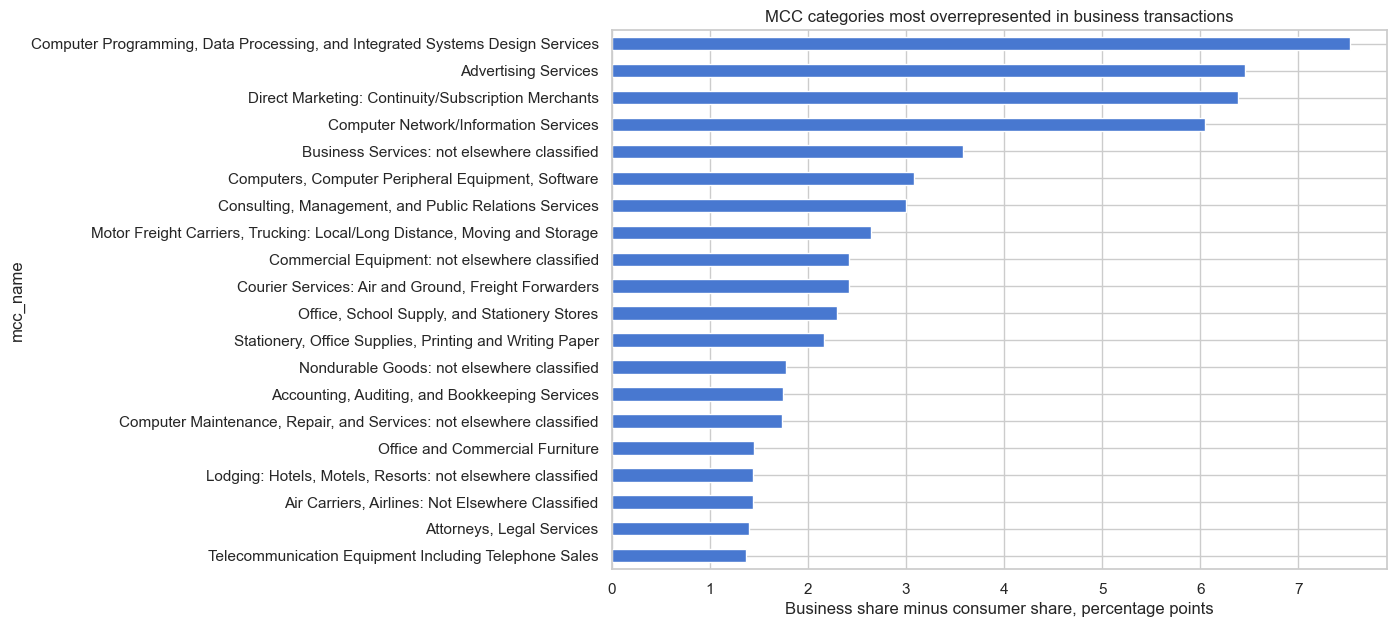

In [26]:
plt.figure(figsize=(10, 7))
mcc_business_over["diff_pp"].sort_values().plot(kind="barh")
plt.title("MCC categories most overrepresented in business transactions")
plt.xlabel("Business share minus consumer share, percentage points")
plt.show()

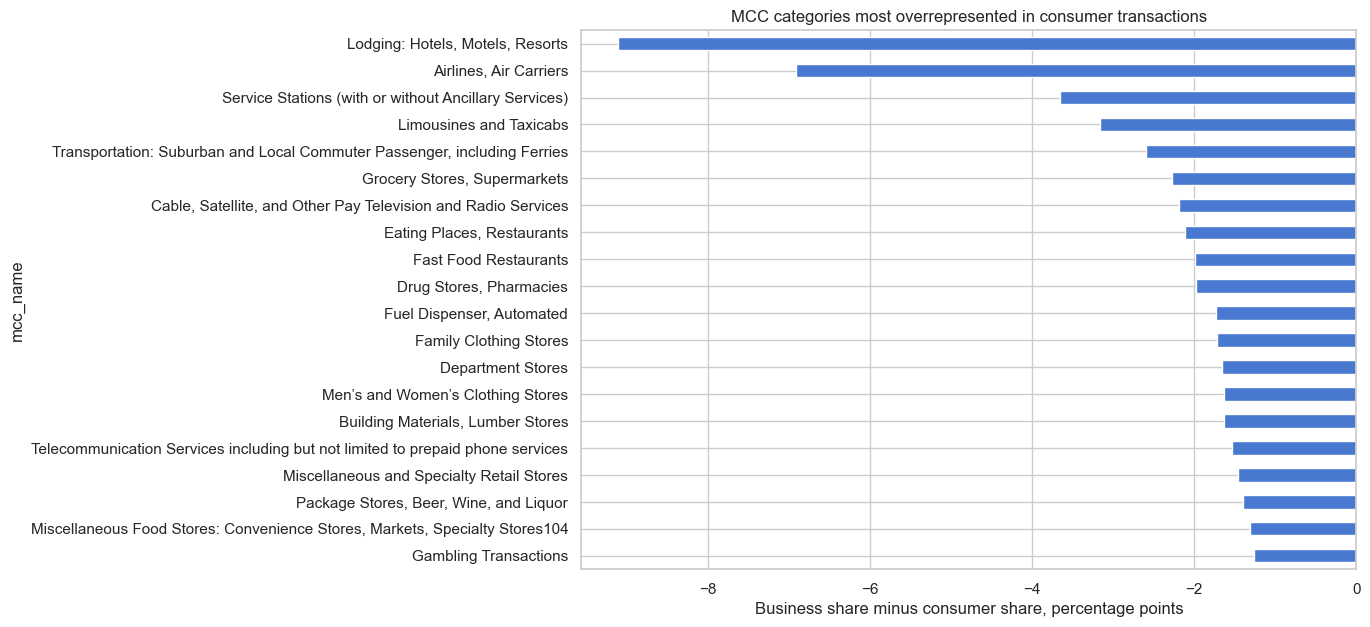

In [27]:
plt.figure(figsize=(10, 7))
mcc_consumer_over["diff_pp"].sort_values(ascending=False).plot(kind="barh")
plt.title("MCC categories most overrepresented in consumer transactions")
plt.xlabel("Business share minus consumer share, percentage points")
plt.show()

### Finding

Business transactions are much more concentrated in work and service related MCC categories.

The biggest differences are in software and IT services, advertising, subscription merchants, information services, business services, consulting, logistics and office supplies.

For example, software and data processing services have around 8.0% of business transactions but only 0.47% of consumer transactions. Advertising services also have 9.1% for business and 2.6% for consumer.

So business cards are not just spending more money. They also spend in different types of categories. These categories look more like company expenses, not daily personal purchases.

### Card-level feature idea

We should not use every MCC code separately as a main feature, because it can become too noisy and hard to explain.

Instead, we can group similar MCCs into business-like groups and calculate card-level ratios later.

For each card we can create features like:

- `software_it_ratio`
- `advertising_ratio`
- `subscription_ratio`
- `business_services_ratio`
- `logistics_ratio`
- `office_supplies_ratio`
- `professional_services_ratio`

These features will show what share of card transactions goes to business-like categories.

This can help us find consumer cards that behave like business cards. For example, if a consumer card has many transactions in ads, software, logistics or business services, it may be more business-like.

In [28]:
B2B_MCC_GROUPS = {
    "advertising": ["7311"],
    "software_it": ["7372", "4816", "5045", "7379"],
    "business_services": ["7399", "7392"],
    "office_supplies": ["5943", "5111"],
    "logistics": ["4214", "4215", "4225"],
    "professional_services": ["8111", "8931", "8999"],
}

In [29]:
rows = []

for group, codes in B2B_MCC_GROUPS.items():
    rows.append({
        "group": group,
        "business": business_txn["mcc"].isin(codes).mean(),
        "consumer": consumer_txn["mcc"].isin(codes).mean(),
    })

b2b_group_compare = pd.DataFrame(rows)
b2b_group_compare["ratio_biz_to_consumer"] = (
    b2b_group_compare["business"] /
    b2b_group_compare["consumer"].replace(0, np.nan)
)

b2b_group_compare.sort_values("business", ascending=False)

,group,business,consumer,ratio_biz_to_consumer
1,software_it,0.19,0.01,22.22
0,advertising,0.09,0.03,3.48
2,business_services,0.07,0.00,36.25
4,logistics,0.06,0.00,13.79
3,office_supplies,0.05,0.00,24.29
5,professional_services,0.03,0.00,27.43


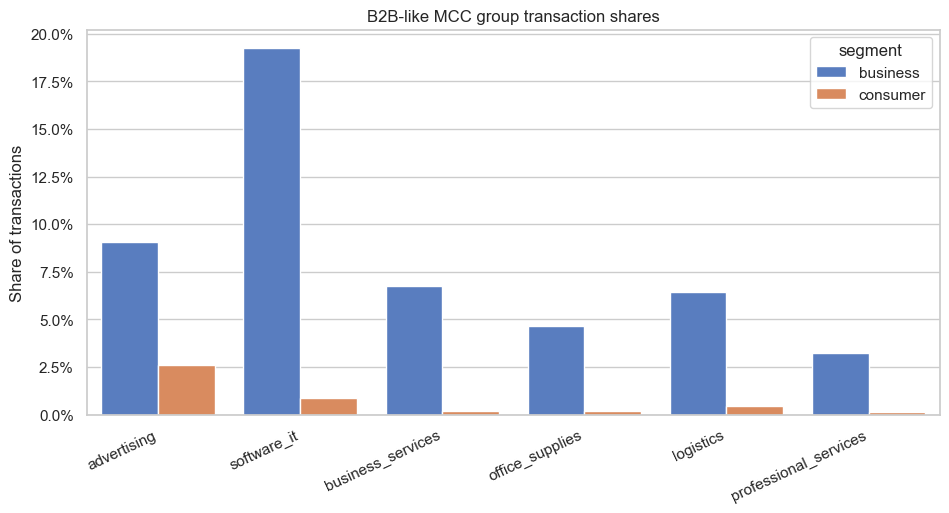

In [30]:
plot_df = b2b_group_compare.melt(
    id_vars=["group", "ratio_biz_to_consumer"],
    value_vars=["business", "consumer"],
    var_name="segment",
    value_name="share"
)

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x="group", y="share", hue="segment")
plt.title("B2B-like MCC group transaction shares")
plt.xlabel("")
plt.ylabel("Share of transactions")
plt.xticks(rotation=25, ha="right")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
plt.show()

### Finding

Business transactions are much more concentrated in B2B-like MCC groups.

The biggest shares for business are advertising, software/cloud, business services and logistics. For example, advertising is about 9.1% of business transactions but only 2.6% of consumer transactions. Software/cloud is about 8.0% for business and only 0.5% for consumer.

Other groups like business services, office supplies, logistics and professional services are also much higher for business.

So this shows that business cards are used more for work related spending. Like ads, software, logistics, office needs and professional services. Consumer cards almost do not use these categories as much.

### Card-level feature idea

This is a useful signal but we should move it to card level later.

For each card we can calculate:

- `advertising_ratio`
- `software_cloud_ratio`
- `business_services_ratio`
- `office_supplies_ratio`
- `logistics_ratio`
- `professional_services_ratio`

These features will show what part of card transactions goes to business-like categories.

This can help us find consumer cards that look like business cards. For example if a consumer card has many payments in ads, software, logistics or business services, it may be more business-like.